In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, datediff, lit, to_date,
    max as _max, sum as _sum, round as _round,
    avg, log1p, desc, when
)
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline
import time, warnings
warnings.filterwarnings("ignore")

# Cấu hình lại SparkSession cho máy yếu
spark = SparkSession.builder \
    .appName("RFM_Clustering") \
    .master("local[2]") \
    .config("spark.driver.memory", "1g") \
    .config("spark.executor.memory", "512m") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()
    
spark.sparkContext.setLogLevel("WARN")
print(f"Spark: {spark.version}")

Spark: 3.4.0


In [2]:
df = spark.read.parquet("/home/jovyan/work/data/rfm_input/")

total = df.count()
users = df.select("user_id").distinct().count()

print(f"Tổng dòng          : {total:,}")
print(f"Khách hàng unique  : {users:,}")
df.show(5, truncate=False)

Tổng dòng          : 562,149
Khách hàng unique  : 233,566
+-------------------+-------------------+-------------------+-------------------+---------------------------+--------+------+-------------------+----------+----+-----+------------+------------+
|event_time         |order_id           |product_id         |category_id        |category_code              |brand   |price |user_id            |date      |year|month|category_lv1|category_lv2|
+-------------------+-------------------+-------------------+-------------------+---------------------------+--------+------+-------------------+----------+----+-----+------------+------------+
|2020-04-26 23:35:39|2296164324487463110|1515966223509259473|2268105402447037312|appliances.personal.scales |polaris |30.07 |1515915625446798439|2020-04-26|2020|4    |appliances  |personal    |
|2020-04-28 02:21:45|2296972701060825130|1515966223509104683|2268105402774193030|unknown                    |philips |23.13 |1515915625451212869|2020-04-28|2020|4    

Tính RFM

In [3]:
SNAPSHOT = "2020-12-01"

rfm_raw = df.groupBy("user_id").agg(
    datediff(lit(SNAPSHOT), to_date(_max("event_time"))).alias("recency"),
    count("*").alias("frequency"),
    _round(_sum("price"), 2).alias("monetary")
).filter(
    (col("recency")   >= 0) &
    (col("monetary")  >  0) &
    (col("frequency") >= 1)
)

print(f"Số khách hàng đưa vào RFM: {rfm_raw.count():,}")
print("\n=== Thống kê RFM ===")
rfm_raw.describe(["recency", "frequency", "monetary"]).show()
rfm_raw.show(10)

Số khách hàng đưa vào RFM: 233,566

=== Thống kê RFM ===
+-------+------------------+------------------+------------------+
|summary|           recency|         frequency|          monetary|
+-------+------------------+------------------+------------------+
|  count|            233566|            233566|            233566|
|   mean|101.58222943407858|2.4068100665336565| 501.8368718906106|
| stddev| 70.71561887458867|3.3759917582161285|1042.1432106475913|
|    min|                10|                 1|              0.02|
|    max|               331|               240|           68035.6|
+-------+------------------+------------------+------------------+

+-------------------+-------+---------+--------+
|            user_id|recency|frequency|monetary|
+-------------------+-------+---------+--------+
|1515915625452183601|    216|        3|   15.67|
|1515915625448774845|    135|        2|  699.03|
|1515915625442535868|    216|        1|   13.87|
|1515915625442596394|     69|        4|  541.

In [4]:
quantiles = rfm_raw.approxQuantile(
    ["recency", "frequency", "monetary"],
    [0.01, 0.99],
    0.05    # sai số 5% — chấp nhận được, nhanh hơn tính chính xác
)

r_low,  r_high  = quantiles[0]
f_low,  f_high  = quantiles[1]
m_low,  m_high  = quantiles[2]

print("=== Ngưỡng outlier ===")
print(f"  Recency   : [{r_low:.0f}, {r_high:.0f}] ngày")
print(f"  Frequency : [{f_low:.0f}, {f_high:.0f}] lần")
print(f"  Monetary  : [{m_low:.0f}, {m_high:.0f}] USD")

rfm_filtered = rfm_raw.filter(
    (col("recency")   >= r_low)  & (col("recency")   <= r_high)  &
    (col("frequency") >= f_low)  & (col("frequency") <= f_high)  &
    (col("monetary")  >= m_low)  & (col("monetary")  <= m_high)
)

before = rfm_raw.count()
after  = rfm_filtered.count()
print(f"\nTrước lọc outlier : {before:,}")
print(f"Sau lọc outlier   : {after:,}")
print(f"Loại bỏ           : {before-after:,} ({(before-after)/before*100:.1f}%)")

# Log transform
rfm_log = rfm_filtered.withColumn("monetary_log", log1p(col("monetary")))
rfm_log.select("user_id","recency","frequency",
               "monetary","monetary_log").show(5)

=== Ngưỡng outlier ===
  Recency   : [10, 331] ngày
  Frequency : [1, 240] lần
  Monetary  : [0, 68036] USD

Trước lọc outlier : 233,566
Sau lọc outlier   : 233,566
Loại bỏ           : 0 (0.0%)
+-------------------+-------+---------+--------+------------------+
|            user_id|recency|frequency|monetary|      monetary_log|
+-------------------+-------+---------+--------+------------------+
|1515915625452183601|    216|        3|   15.67| 2.813610696762703|
|1515915625448774845|    135|        2|  699.03| 6.551123191267921|
|1515915625442535868|    216|        1|   13.87|2.6993457604720636|
|1515915625442596394|     69|        4|  541.34|6.2958931110383745|
|1515915625445509879|    216|        1|   54.61| 4.018363041199472|
+-------------------+-------+---------+--------+------------------+
only showing top 5 rows



In [5]:
# Cache rfm_log vào memory — quan trọng!
rfm_log.cache()
rfm_log.count()  # trigger cache ngay
print("Cache xong!")

Cache xong!


In [6]:

# Lấy sample 30% để Elbow chạy nhanh hơn
# Kết quả vẫn đủ chính xác để chọn k
rfm_sample = rfm_log.sample(fraction=0.3, seed=42)

assembler_e = VectorAssembler(
    inputCols=["recency", "frequency", "monetary_log"],
    outputCol="features_raw"
)
scaler_e = StandardScaler(
    inputCol="features_raw", outputCol="features",
    withStd=True, withMean=True
)
pipe_prep = Pipeline(stages=[assembler_e, scaler_e])
df_scaled  = pipe_prep.fit(rfm_sample).transform(rfm_sample)

costs   = []
K_range = range(3, 6)   # chỉ thử k=3,4,5 thay vì 2..7

for k in K_range:
    km   = KMeans(featuresCol="features", k=k, seed=42, maxIter=10)
    m    = km.fit(df_scaled)
    cost = m.summary.trainingCost
    costs.append(cost)
    print(f"  k={k}  WSSSE={cost:,.0f}")

  k=3  WSSSE=121,030
  k=4  WSSSE=92,935
  k=5  WSSSE=80,819


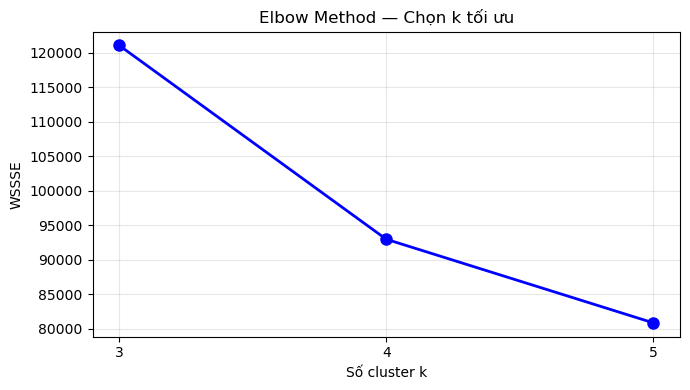

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), costs, "bo-", linewidth=2, markersize=8)
plt.xlabel("Số cluster k")
plt.ylabel("WSSSE")
plt.title("Elbow Method — Chọn k tối ưu")
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/home/jovyan/work/data/elbow.png", dpi=120)
plt.show()

In [8]:
assembler = VectorAssembler(
    inputCols=["recency", "frequency", "monetary_log"],
    outputCol="features_raw"
)
scaler = StandardScaler(
    inputCol="features_raw", outputCol="features",
    withStd=True, withMean=True
)
kmeans = KMeans(featuresCol="features", k=4, seed=42, maxIter=30)

pipeline = Pipeline(stages=[assembler, scaler, kmeans])
model    = pipeline.fit(rfm_log)
rfm_pred = model.transform(rfm_log)

print("=== Đặc trưng từng cluster ===")
rfm_pred.groupBy("prediction").agg(
    _round(avg("recency"),   1).alias("avg_R_ngay"),
    _round(avg("frequency"), 1).alias("avg_F_lan"),
    _round(avg("monetary"),  1).alias("avg_M_USD"),
    count("*").alias("so_khach")
).orderBy("prediction").show()

=== Đặc trưng từng cluster ===
+----------+----------+---------+---------+--------+
|prediction|avg_R_ngay|avg_F_lan|avg_M_USD|so_khach|
+----------+----------+---------+---------+--------+
|         0|      80.9|      2.5|    742.0|  107440|
|         1|      57.7|      1.5|     56.4|   66315|
|         2|      78.8|     14.8|   3092.8|    7596|
|         3|     203.1|      1.6|    196.4|   52215|
+----------+----------+---------+---------+--------+



In [9]:
# Gán nhãn RFM dựa trên phân tích đặc trưng Cluster
rfm_labeled = rfm_pred.withColumn("segment",
    when(col("prediction") == 2, "VIP")
    .when(col("prediction") == 0, "Loyal")
    .when(col("prediction") == 1, "New")
    .when(col("prediction") == 3, "Lost")
    .otherwise("Unknown") # Thêm otherwise để tránh lỗi dữ liệu (nếu có)
)

print("=== Phân bố segment ===")
rfm_labeled.groupBy("segment").agg(
    count("*").alias("so_khach"),
    _round(avg("recency"),   1).alias("avg_recency_ngay"),
    _round(avg("frequency"), 1).alias("avg_so_lan_mua"),
    _round(avg("monetary"),  1).alias("avg_tong_tien_USD")
).orderBy("so_khach", ascending=False).show()

=== Phân bố segment ===
+-------+--------+----------------+--------------+-----------------+
|segment|so_khach|avg_recency_ngay|avg_so_lan_mua|avg_tong_tien_USD|
+-------+--------+----------------+--------------+-----------------+
|  Loyal|  107440|            80.9|           2.5|            742.0|
|    New|   66315|            57.7|           1.5|             56.4|
|   Lost|   52215|           203.1|           1.6|            196.4|
|    VIP|    7596|            78.8|          14.8|           3092.8|
+-------+--------+----------------+--------------+-----------------+



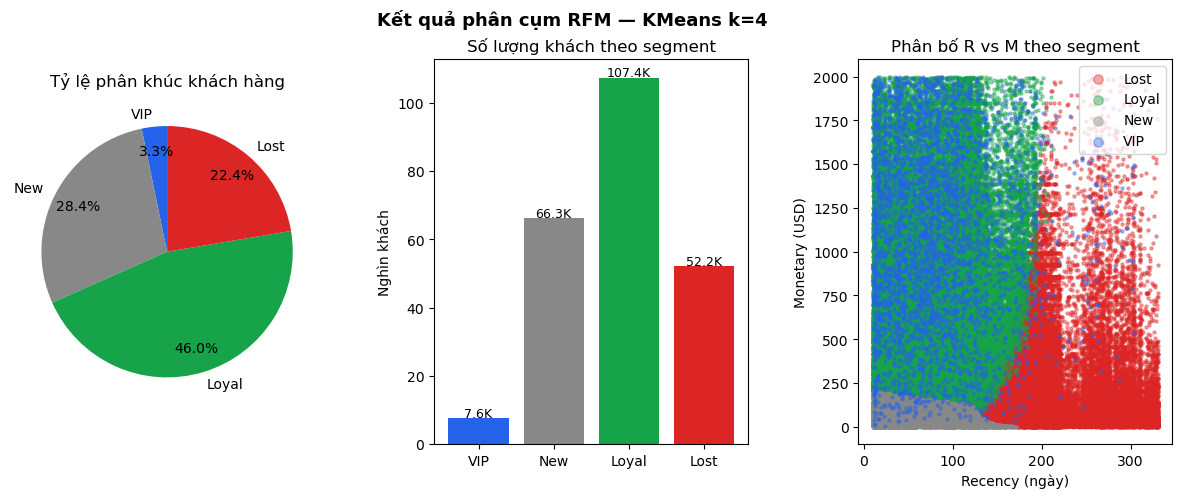

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

seg_pd = rfm_labeled.groupBy("segment").count().toPandas()
rfm_pd = rfm_labeled.select(
    "recency", "frequency", "monetary", "segment"
).filter(col("monetary") < 2000).toPandas()

COLORS = {
    "VIP"    : "#2563EB",
    "Loyal"  : "#16A34A",
    "At Risk": "#F59E0B",
    "Lost"   : "#DC2626"
}

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Pie chart ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
colors = [COLORS.get(s, "#888") for s in seg_pd["segment"]]
ax1.pie(
    seg_pd["count"],
    labels=seg_pd["segment"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    pctdistance=0.8
)
ax1.set_title("Tỷ lệ phân khúc khách hàng")

# ── Bar chart ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.bar(
    seg_pd["segment"],
    seg_pd["count"] / 1000,
    color=colors
)
ax2.set_title("Số lượng khách theo segment")
ax2.set_ylabel("Nghìn khách")
for i, v in enumerate(seg_pd["count"]):
    ax2.text(i, v/1000 + 0.3,
             f"{v/1000:.1f}K",
             ha="center", fontsize=9)

# ── Scatter R vs M ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
for seg, grp in rfm_pd.groupby("segment"):
    ax3.scatter(
        grp["recency"], grp["monetary"],
        label=seg, alpha=0.4, s=5,
        color=COLORS.get(seg, "#888")
    )
ax3.set_xlabel("Recency (ngày)")
ax3.set_ylabel("Monetary (USD)")
ax3.set_title("Phân bố R vs M theo segment")
ax3.legend(markerscale=3)

plt.suptitle("Kết quả phân cụm RFM — KMeans k=4",
             fontsize=13, fontweight="bold")
plt.savefig("/home/jovyan/work/data/rfm_segments.png",
            dpi=120, bbox_inches="tight")
plt.show()

In [11]:
# Lưu Parquet
rfm_labeled.select(
    "user_id", "recency", "frequency", "monetary", "segment"
).write.mode("overwrite") \
 .parquet("/home/jovyan/work/data/rfm_result/")
print("Parquet lưu xong!")

# Ghi vào Cassandra
try:
    rfm_labeled.select(
        col("user_id"),
        col("recency").cast("int"),
        col("frequency").cast("int"),
        col("monetary").cast("double"),
        col("segment")
    ).write \
        .format("org.apache.spark.sql.cassandra") \
        .option("keyspace", "ecommerce") \
        .option("table",    "customer_segments") \
        .mode("append") \
        .save()
    print("Cassandra lưu xong!")
except Exception as e:
    print(f"Cassandra skip: {e}")

print("\nRFM Clustering hoàn tất!")
print(f"Kết quả lưu tại: /home/jovyan/work/data/rfm_result/")

Parquet lưu xong!
Cassandra skip: An error occurred while calling o672.save.
: org.apache.spark.SparkClassNotFoundException: [DATA_SOURCE_NOT_FOUND] Failed to find the data source: org.apache.spark.sql.cassandra. Please find packages at `https://spark.apache.org/third-party-projects.html`.
	at org.apache.spark.sql.errors.QueryExecutionErrors$.dataSourceNotFoundError(QueryExecutionErrors.scala:738)
	at org.apache.spark.sql.execution.datasources.DataSource$.lookupDataSource(DataSource.scala:647)
	at org.apache.spark.sql.execution.datasources.DataSource$.lookupDataSourceV2(DataSource.scala:697)
	at org.apache.spark.sql.DataFrameWriter.lookupV2Provider(DataFrameWriter.scala:860)
	at org.apache.spark.sql.DataFrameWriter.saveInternal(DataFrameWriter.scala:256)
	at org.apache.spark.sql.DataFrameWriter.save(DataFrameWriter.scala:247)
	at java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)
	at java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke(NativeMethod